# Superstore Sales Analysis

This project analyzes e-commerce transactional data to identify sales trends, customer behavior, and operational insights. The analysis includes category performance, regional sales distribution, customer segmentation, and shipping efficiency.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Section 1: Cleaning

# Loading the DATASET and checking the Structure

In [3]:
df = pd.read_csv("superstore_clean.csv")
df.head()
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9792 non-null   float64
 1   Order ID       9792 non-null   str    
 2   Order Date     9792 non-null   str    
 3   Ship Date      9792 non-null   str    
 4   Ship Mode      9792 non-null   str    
 5   Customer ID    9792 non-null   str    
 6   Customer Name  9792 non-null   str    
 7   Segment        9792 non-null   str    
 8   Country        9792 non-null   str    
 9   City           9792 non-null   str    
 10  State          9792 non-null   str    
 11  Postal Code    9781 non-null   float64
 12  Region         9792 non-null   str    
 13  Product ID     9792 non-null   str    
 14  Category       9792 non-null   str    
 15  Sub-Category   9792 non-null   str    
 16  Product Name   9792 non-null   str    
 17  Sales          9792 non-null   float64
dtypes: float64(3), str(

,Row ID,Postal Code,Sales
count,9792.000000,9781.000000,9792.000000
mean,4901.211908,55289.480728,230.784894
std,2828.719699,32044.254104,626.890652
min,1.000000,1040.000000,0.440000
25%,2451.750000,23223.000000,17.235000
50%,4901.500000,58103.000000,54.380000
75%,7350.250000,90008.000000,210.432500
max,9800.000000,99301.000000,22638.480000


# Converting dates

In [4]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

# Creating Time Columns

In [5]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month Name'] = df['Order Date'].dt.month_name()

# Creating a Total Sales Column

In [6]:
total_sales = df['Sales'].sum()
print("Total Sales:", total_sales)

Total Sales: 2259845.68


# Section 2: Analysis

# Sales by Category Bar Llot

Category
Technology         827061.64
Furniture          728091.00
Office Supplies    704693.04
Name: Sales, dtype: float64


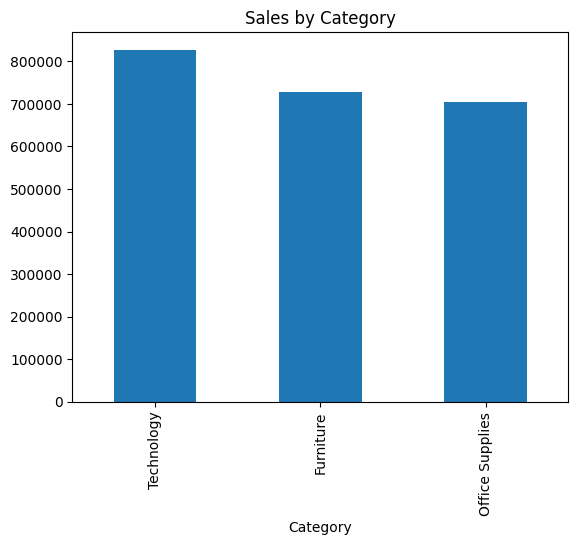

In [7]:
sales_category = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print(sales_category)

sales_category.plot(kind='bar')
plt.title("Sales by Category")
plt.show()

This chart shows total sales generated by each product category.  
Understanding category performance helps businesses identify which product lines contribute the most revenue and where to focus marketing and inventory efforts. 

# Sales by Region Bar plot

Region
Central    492646.90
East       668643.98
South      388437.37
West       710117.43
Name: Sales, dtype: float64


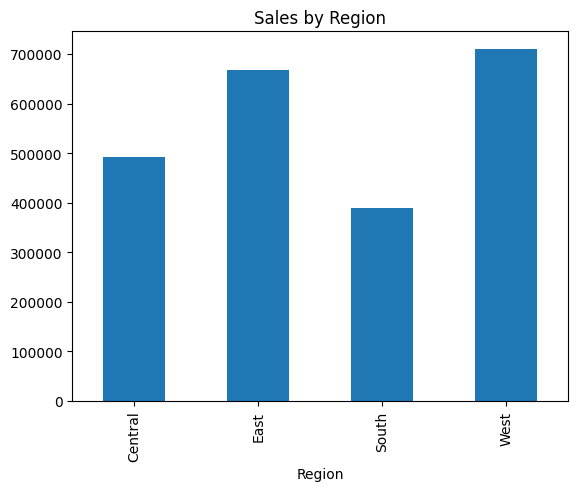

In [8]:
sales_region = df.groupby('Region')['Sales'].sum()
print(sales_region)

sales_region.plot(kind='bar')
plt.title("Sales by Region")
plt.show()

This visualization displays total sales across different regions.  
It helps identify geographic areas with strong performance and regions that may require targeted marketing or operational improvements.

# Top 5 Products Horizantal bar plot

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.83
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.38
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.48
HON 5400 Series Task Chairs for Big and Tall                                   21870.57
GBC DocuBind TL300 Electric Binding System                                     19823.48
Name: Sales, dtype: float64


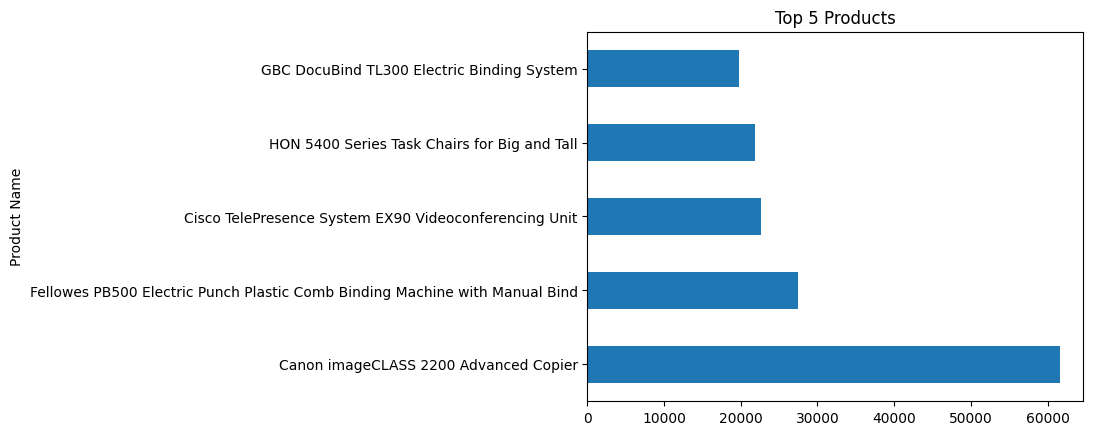

In [22]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(5)
print(top_products)

top_products.plot(kind='barh')
plt.title("Top 5 Products")
plt.show()

This chart highlights the top-performing products based on total sales.  
Identifying best-selling products helps businesses prioritize inventory management and promotional strategies.

# Sales by Sub-Category Bar plot

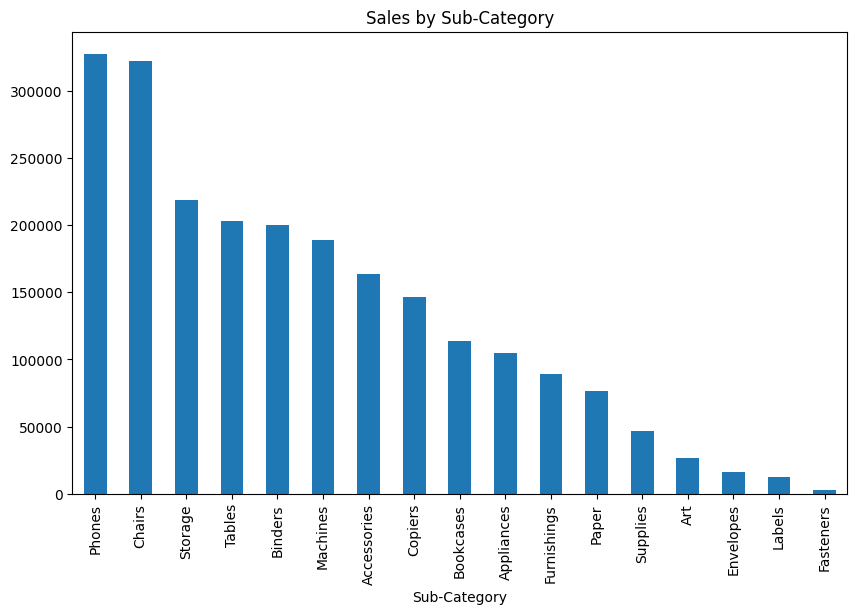

In [19]:
subcat = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
subcat.plot(kind='bar')
plt.title("Sales by Sub-Category")
plt.show()

# Shipping Delay by Ship Mode

In [21]:
df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days

df.groupby('Ship Mode')['Shipping Days'].mean()

Ship Mode
First Class       2.179333
Same Day          0.044610
Second Class      3.250132
Standard Class    5.008711
Name: Shipping Days, dtype: float64

This analysis shows the average number of shipping days for each shipping mode.  
Analyzing shipping performance helps evaluate operational efficiency and customer delivery experience.

# Exporting the Final Cleaned Csv

In [23]:
df.to_csv("superstore_cleaned_final.csv", index=False)

## Key Insights

- Technology and Furniture having the most sales especially the phones and chairs having more than 300000 sales each.
- Sales vary significantly across regions with the west having almost double the sales of the south.
- A small number of products contribute heavily to total sales, with the top 5 being tech products.
- Shipping modes impact delivery time and operational efficiency which is why most customers choose the standard class for shipping.